#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package to navigate through files and folders
import os

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart

# import of modules important for locking
from opentnsim.lock import lock as lock_module
from opentnsim.vessel_traffic_service import vessel_traffic_service as vessel_traffic_service_module

# energy module packages added from 0103 notebook
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table)
from opentnsim.graph import mixins as graph_module

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

# package(s) needed for inspecting the output
import pandas as pd
import geopandas as gpd
import numpy as np

# plot libraries
import folium
import pickle

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


#### 

In [2]:
path = os.getcwd()
# lock_information = pickle.load(open(os.path.join(path, "..", "data", "lock_information.pickle"),'rb'))
lock_information = pickle.load(open(os.path.join(path, "data", "lock_information.pickle"),'rb'))

In [3]:
sub_FG = lock_information['modified_graph']
lock_length = lock_information["lock_length"]
lock_depth = lock_information["lock_depth"]
node_A = lock_information["registration_node_A"]
node_B = lock_information["registration_node_B"]

In [4]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.mixins.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 1. Run simulation
##### 1.1 Set mission and simpy environment with VTS

In [5]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [6]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# This is not the best way to assign the lock_depth but it works 
# Add constant general depth
for u, v in sub_FG.edges():
    # FG.edges[u, v]['GeneralDepth'] = 6
    sub_FG.edges[u, v]['GeneralDepth'] = lock_depth
    
env.graph = sub_FG

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=sub_FG, crs_m = "EPSG:28992") #Amersfoort / RD New reference system

##### 3.2 Create lock object

In [7]:
waiting_time_before_lock = 1000 #seconds

lock = lock_module.IsLockComplex(
    env = env,
    name = 'Lock',
    node_open = lock_information["lock_node_A"],
    node_A = lock_information["lock_node_A"],
    node_B = lock_information["lock_node_B"],
    edge_waiting_area_A = lock_information["edge_waiting_area_A"], 
    edge_waiting_area_B = lock_information["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = 500.,
    distance_lock_doors_B_to_waiting_area_B = 500.,
    distance_from_start_node_to_lock_doors_A = lock_information["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = lock_information["distance_from_end_node_to_lock_doors_B"],
    speed_reduction_length_before_waiting_area = 600,
    sailing_out_speed_A = 1.5,
    sailing_out_speed_B = 1.5,
    speed_reduction_factor = 0.5,
    speed_reduction_factor_waiting_area_A = 0.5,
    speed_reduction_factor_waiting_area_B = 0.5,
    lock_length = lock_information["lock_length"],
    lock_width = lock_information["lock_width"],
    lock_depth = lock_information["lock_depth"],
    mandatory_waiting_time_before_lock = waiting_time_before_lock,
    levelling_time = 600,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    sailing_in_speed_sea = 1.0,
    sailing_in_speed_canal = 1.0,
    registration_nodes = [lock_information["registration_node_A"], lock_information["registration_node_B"]],
)

500.0

In [8]:
# print(lock_information["lock_depth"])
# print(lock.lock_depth)

##### 3.3 Create vessels

In [9]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,
    "name": 'Vessel',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 250,                   # m (fictive, to better match AIS data)
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": False, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2025, 9, 2, 8, 58, 0),
    # "geometry": env.graph.nodes[route[0]]['geometry'],
    # "route": route,             # the route to sail
    "geometry": env.graph.nodes[node_A]['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, node_A, node_B),      # required by Routeable
}  #  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

# start the simulation
env.process(mission(env, vessel_1))
env.run()

In [10]:
trajectory_gdf = pickle.load(open(os.path.join(path, "data", "volkerak_track.pickle"),'rb'))

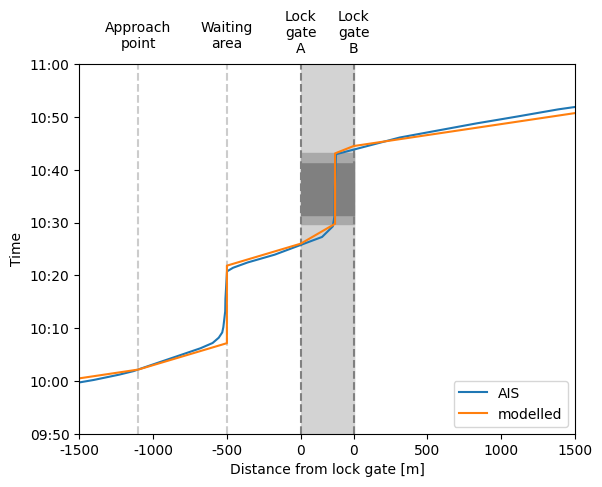

In [90]:
# Het lukt me even niet om de modelled en AIS tegelijk te plotten
# Het lijkt alsof er iets is veranderd in def lock.create_time_distance_plot

xlimmin = -1500 - lock_information["lock_length"]/2
xlimmax = 1500 + lock_information["lock_length"]/2
ylimmin = pd.Timestamp('2025-09-02 9:50:00')
ylimmax = pd.Timestamp('2025-09-02 11:00:00')

# We can plot the time-distance diagram
fig,ax = plt.subplots()

ax.plot(trajectory_gdf.distance_cumulative,trajectory_gdf.index, label='AIS')
lock.create_time_distance_plot([vessel_1], xlimmin = xlimmin, xlimmax = xlimmax, ax = ax, label='modelled')

ax.set_xlim([xlimmin,xlimmax])
ax.fill([-lock_length/2,-lock_length/2,lock_length/2,lock_length/2],
        [ylimmin,ylimmax,ylimmax,ylimmin],color='lightgrey',zorder=-1)
ax.set_ylim([ylimmin,ylimmax])
xticks_left = np.arange(xlimmin,0,500)
xticklabels_left = np.arange(-1500,500,500)
xticks_right = np.arange(lock_information["lock_length"]/2,xlimmax+200,500)
xticklabels_right = np.arange(0,2000,500)
xticks = np.append(xticks_left,xticks_right)
xticklabels = np.append(xticklabels_left,xticklabels_right)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Distance from lock gate [m]')
ax.set_ylabel('Time')
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
speed_reduction_distance_A = -lock.speed_reduction_length_before_waiting_area - lock_information["lock_length"]/2 - lock.distance_lock_doors_A_to_waiting_area_A
ax.axvline(speed_reduction_distance_A, color=[0.8,0.8,0.8], linestyle='--',zorder = -1)
waiting_area_distance_A =  - lock_information["lock_length"]/2 - lock.distance_lock_doors_A_to_waiting_area_A
ax.axvline(waiting_area_distance_A, color=[0.8,0.8,0.8], linestyle='--',zorder = -1)
ax.annotate(
    'Waiting\narea',
    (waiting_area_distance_A, ylimmax),
    xytext=(0, 12),
    textcoords='offset points',
    ha='center'
)
ax.annotate(
    'Approach\npoint',
    (speed_reduction_distance_A, ylimmax),
    xytext=(0, 12),
    textcoords='offset points',
    ha='center'
)
ax.axvline(-lock_length/2, color=[0.5,0.5,0.5], linestyle='--',zorder = 0)
ax.axvline(lock_length/2, color=[0.5,0.5,0.5], linestyle='--',zorder = 0)
ax.annotate(
    'Lock\ngate\nA',
    (-lock_length/2, ylimmax),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)
ax.annotate(
    'Lock\ngate\nB',
    (lock_length/2, ylimmax),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)
ax.legend()
plt.show()

In [61]:
ylimmax

Timestamp('2025-09-02 11:00:00')

In [13]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8860743 to node 8862498 start,2025-09-02 09:58:00.000000,0,POINT (4.43615944214078 51.7022764335403)
1,Sailing from node 8860743 to node 8862498 stop,2025-09-02 09:59:59.152925,476.611698,POINT (4.43027504290525 51.7000442261129)
2,Sailing from node 8862498 to node B34113_A start,2025-09-02 09:59:59.152925,476.611698,POINT (4.43027504290525 51.7000442261129)
3,Sailing to waiting area start,2025-09-02 09:59:59.152925,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.43027504290525 51.7000442261129)
4,Sailing to waiting area stop,2025-09-02 10:02:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.42400509866192 51.69747197574123)
5,Sailing to waiting area start (with reduced sp...,2025-09-02 10:02:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.42400509866192 51.69747197574123)
6,Sailing to waiting area stop (with reduced speed),2025-09-02 10:07:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)
7,Waiting for lock operation start,2025-09-02 10:07:09.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)
8,Waiting for lock operation stop,2025-09-02 10:21:49.854830,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)
9,Sailing to first lock doors start,2025-09-02 10:21:49.854830,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251674 51.69396139614889)


In [14]:
lock.operation_planning.iloc[0]

node_from                                                                          8862498
node_to                                                                           B34113_A
direction                                                                                0
lock_chamber                                                                          Lock
vessels                                   [<__main__.Vessel object at 0x000001EE77CF01A0>]
capacity_L                                                                      107.101557
capacity_B                                                                       18.438854
time_potential_lock_door_opening_stop                        2025-09-02 10:11:24.854830572
time_operation_start                                         2025-09-02 10:18:54.854830572
time_entry_start                                             2025-09-02 10:21:24.854830572
time_entry_stop                                              2025-09-02 10:25:10.439497812

In [15]:
lock.vessel_planning.iloc[0]

id                                        56645911-7dd7-45cb-8556-8587352df72d
node_from                                                              8862498
node_to                                                               B34113_A
lock_chamber                                                               NaN
L                                                                          250
B                                                                         11.4
T                                                                          3.5
operation_index                                                              0
time_of_registration                                       2025-09-02 09:58:00
time_of_acceptance                                         2025-09-02 09:58:00
time_potential_lock_door_opening_stop            2025-09-02 10:11:24.854830572
time_arrival_at_waiting_area                     2025-09-02 10:05:09.854830572
time_arrival_at_lineup_area                         

In [16]:
df_eventtable = logbook2eventtable([vessel_1])
# df_eventtable.head(5)
df_eventtable
# print("'{}' logbook data:".format(vessel_1.name))  

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8860743 to node 8862498,,POINT (4.43615944214078 51.7022764335403),POINT (4.43027504290525 51.7000442261129),2025-09-02 09:58:00,2025-09-02 09:59:59,476.611698,119.152925
1,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.42400509866192 51.69747197574123),2025-09-02 09:59:59,2025-09-02 10:02:09,538.500000,130.000000
2,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417425659251674 51.69396139614889),POINT (4.411964025200449 51.691016098663965),2025-09-02 10:21:50,2025-09-02 10:26:00,493.060000,250.000000
3,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:26:00,2025-09-02 10:29:45,229.150000,225.000000
4,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:29:45,2025-09-02 10:31:25,0.000000,100.000000
5,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:31:25,2025-09-02 10:41:25,0.000000,600.000000
6,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:41:25,2025-09-02 10:43:05,0.000000,100.000000
7,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.4094223796274425 51.68965346008542),POINT (4.408054344012045 51.68891905583165),2025-09-02 10:43:05,2025-09-02 10:44:29,123.380000,84.000000
8,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node B34113_A to node B34113_B,,POINT (4.4077088440752465 51.688733575668216),POINT (4.407620736969263 51.688686277276325),2025-09-02 10:44:37,2025-09-02 10:44:39,8.050553,2.012639
9,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node B34113_B to node 8868426,,POINT (4.407620736969263 51.688686277276325),POINT (4.39253941691783 51.6812485487213),2025-09-02 10:44:39,2025-09-02 10:50:12,1331.492705,332.873176


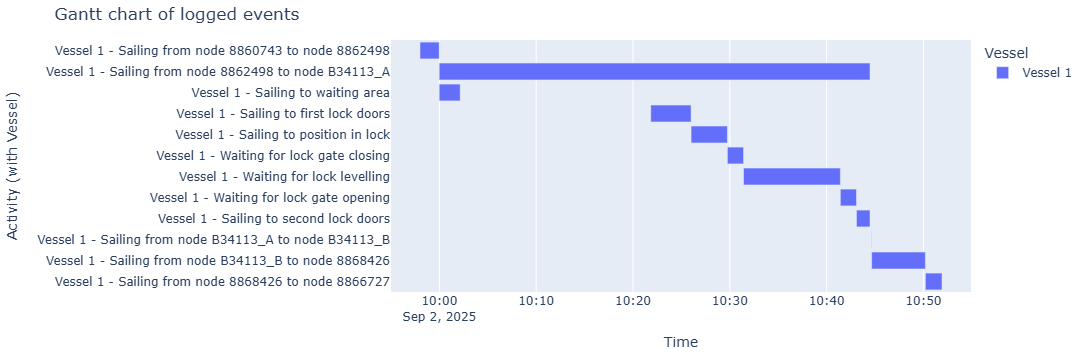

In [17]:
generate_vessel_gantt_chart(df_eventtable)

In [18]:
# add energy attributes to the minimum event table
lock_depth = lock_information["lock_depth"]
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1])        

# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8860743 to node 8862498,,POINT (4.43615944214078 51.7022764335403),POINT (4.43027504290525 51.7000442261129),2025-09-02 09:58:00,2025-09-02 09:59:59,476.611698,119.152925,4.000000,6.2,None,0.0,1100.183987,1100.183987,1750.0,36.413928
1,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.42400509866192 51.69747197574123),2025-09-02 09:59:59,2025-09-02 10:02:09,538.500000,130.000000,4.142308,6.2,None,0.0,1217.749417,1217.749417,1750.0,43.974284
2,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417425659251674 51.69396139614889),POINT (4.411964025200449 51.691016098663965),2025-09-02 10:21:50,2025-09-02 10:26:00,493.060000,250.000000,1.972240,6.2,None,0.0,205.645274,205.645274,1750.0,14.280922
3,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:26:00,2025-09-02 10:29:45,229.150000,225.000000,1.018444,6.2,None,0.0,105.000396,105.000396,1750.0,6.562525
4,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:29:45,2025-09-02 10:31:25,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556
5,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:31:25,2025-09-02 10:41:25,0.000000,600.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,14.583333
6,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:41:25,2025-09-02 10:43:05,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556
7,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.4094223796274425 51.68965346008542),POINT (4.408054344012045 51.68891905583165),2025-09-02 10:43:05,2025-09-02 10:44:29,123.380000,84.000000,1.468810,6.2,None,0.0,137.744643,137.744643,1750.0,3.214042
8,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node B34113_A to node B34113_B,,POINT (4.4077088440752465 51.688733575668216),POINT (4.407620736969263 51.688686277276325),2025-09-02 10:44:37,2025-09-02 10:44:39,8.050553,2.012639,3.999999,6.2,None,0.0,1100.182937,1100.182937,1750.0,0.615075
9,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node B34113_B to node 8868426,,POINT (4.407620736969263 51.688686277276325),POINT (4.39253941691783 51.6812485487213),2025-09-02 10:44:39,2025-09-02 10:50:12,1331.492705,332.873176,4.000000,6.2,None,0.0,1100.184000,1100.184000,1750.0,101.728262


In [19]:
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable, [vessel_1])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8860743 to node 8862498,,POINT (4.43615944214078 51.7022764335403),POINT (4.43027504290525 51.7000442261129),2025-09-02 09:58:00,2025-09-02 09:59:59,476.611698,119.152925,4.000000,6.2,None,0.0,1100.183987,1100.183987,1750.0,36.413928,2721.628237,5.710368,22.841472
1,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.42400509866192 51.69747197574123),2025-09-02 09:59:59,2025-09-02 10:02:09,538.500000,130.000000,4.142308,6.2,None,0.0,1217.749417,1217.749417,1750.0,43.974284,3286.699942,6.103435,25.282307
2,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417425659251674 51.69396139614889),POINT (4.411964025200449 51.691016098663965),2025-09-02 10:21:50,2025-09-02 10:26:00,493.060000,250.000000,1.972240,6.2,None,0.0,205.645274,205.645274,1750.0,14.280922,1067.376202,2.164800,4.269505
3,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:26:00,2025-09-02 10:29:45,229.150000,225.000000,1.018444,6.2,None,0.0,105.000396,105.000396,1750.0,6.562525,490.492339,2.140486,2.179966
4,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:29:45,2025-09-02 10:31:25,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556,181.663145,0.000000,1.816631
5,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:31:25,2025-09-02 10:41:25,0.000000,600.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,14.583333,1089.978868,0.000000,1.816631
6,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.4094223796274425 51.68965346008542),POINT (4.4094223796274425 51.68965346008542),2025-09-02 10:41:25,2025-09-02 10:43:05,0.000000,100.000000,0.000000,6.2,None,0.0,87.500000,87.500000,1750.0,2.430556,181.663145,0.000000,1.816631
7,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.4094223796274425 51.68965346008542),POINT (4.408054344012045 51.68891905583165),2025-09-02 10:43:05,2025-09-02 10:44:29,123.380000,84.000000,1.468810,6.2,None,0.0,137.744643,137.744643,1750.0,3.214042,240.221999,1.947009,2.859786
8,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node B34113_A to node B34113_B,,POINT (4.4077088440752465 51.688733575668216),POINT (4.407620736969263 51.688686277276325),2025-09-02 10:44:37,2025-09-02 10:44:39,8.050553,2.012639,3.999999,6.2,None,0.0,1100.182937,1100.182937,1750.0,0.615075,45.971594,5.710365,22.841451
9,56645911-7dd7-45cb-8556-8587352df72d,Vessel 1,Sailing from node B34113_B to node 8868426,,POINT (4.407620736969263 51.688686277276325),POINT (4.39253941691783 51.6812485487213),2025-09-02 10:44:39,2025-09-02 10:50:12,1331.492705,332.873176,4.000000,6.2,None,0.0,1100.184000,1100.184000,1750.0,101.728262,7603.313526,5.710368,22.841473


In [20]:
# Event totals + unit conversion + speed 
df_event = (
    df_eventtable
    .groupby('object name')
    .agg({'duration (s)': 'sum', 'distance (m)': 'sum'})
)
# df_event['duration (h)']      = df_event['duration (s)'] / 3600
df_event['duration (min)']      = df_event['duration (s)'] / 60
df_event['distance (km)']     = df_event['distance (m)'] / 1000
df_event['avg_speed_m_s']     = df_event['distance (m)'] / df_event['duration (s)']
# df_event['avg_speed_km_h']    = df_event['avg_speed_m_s'] * 3.6

# H2 energy & fuel
df_H2 = (
    df_eventtable_energy_H2
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'H2_consumption (g)': 'sum'})
)
df_H2['H2_consumption (kg)'] = df_H2['H2_consumption (g)'] / 1000

# --- Final summary table ---
summary = (
    df_event
    .join(df_H2[['H2_consumption (kg)']])
)

summary

,duration (s),distance (m),duration (min),distance (km),avg_speed_m_s,H2_consumption (kg)
object name,,,,,,
Vessel 1,2046.794936,3615.269741,34.113249,3.61527,1.766308,19.278953
